# **Business Understanding**

*context:*
Customer churn is a significant business concern for telecommunications companies because losing existing customers can reduce recurring revenue and increase the cost associated with acquiring replacement customers. Therefore, understanding which customers are likely to churn can enable a telecommunications company to take proactive retention actions.

*Problem Statement:*
How can a telecommunications company use customer data and AI to identify customers who are at greater risk of churning, understand the factors associated with churn, and support proactive customer-retention decisions?


*About Data:*
This sample data module tracks a fictional telco company's customer churn based on various factors. T he churn column indicates whether the customer departed within the last month. Other columns include gender, dependents, monthly charges, and many with information about the types of services each customer has.

*Objectives:*
- To analyse historical patterns of customer churn
- To develop an AI/ML model capable of predicting the likelihood of customer churn
- To segment customers according to their level of churn risk
- To identify customer characteristics and behaviours associated with churn

*Relevant Source(s):*
- [telco-customer-churn-on-icp4d](https://github.com/IBM/telco-customer-churn-on-icp4d)
- [About Telco customer churn](https://www.ibm.com/docs/en/cognos-analytics/12.1.x?topic=samples-telco-customer-churn)
- [Desk-based Research ](https://elicit.com/artifact/ccce3de9-18a8-418b-8563-4b619089bc96?share_ref=3a69ab2a-a154-40ec-a4eb-80c5bc9aa4b6)

#### **Load Libraries**

In [2]:
# !pip install xgboost

In [55]:
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve, precision_score, recall_score, f1_score, accuracy_score)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline


In [4]:
# constants: 
SEED_VALUE = 42
tf.keras.utils.set_random_seed(SEED_VALUE)   # makes results repeatable 


#### **Load data**

In [5]:
df = pd.read_csv("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/refs/heads/master/data/Telco-Customer-Churn.csv")

# **Data Understanding & Preparation**

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [8]:
df.shape

(7043, 21)

##### **Univariate Analysis**

In [9]:
df_2 = df.drop(columns=["customerID"])

In [10]:
df_2.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [11]:
df.customerID.nunique()

7043

In [12]:
df_2.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [13]:
df_2.SeniorCitizen.value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [14]:
df_2[df_2["tenure"] == 0].head(2) # possible new customers

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No


In [15]:
tenures = df_2["tenure"].unique()
tenures.sort()
tenures

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72])

In [16]:
df_2.MonthlyCharges.describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

- Customer size is 7043 

**SeniorCitizen:**
-  Binary in nature, 0 representsot seniorcitizen while 1 represents senior citizen
-  5901 are not Senior citizrns but 1142 are Senior Citizens

**tenure:**
- One average the customers ppurchased producin a duration ff 32.37 months
- the variation between each customer duration was appprooximately 24 months
- 75% of the customers fell below 55% in terms of their purchase durations
- 50% of the customer population fell below 29 months
- 25% of the customer population fell below 9 months
- the time period rangers from 0 - 72 with a center point of 20

**MonthlyCharges:**
- Avg mnthly charge is 64.76 
- The highest bill is at 118
- 75% of the bills fall below 89.5
- 50% of the bills fall below 70.35
- 25% of the bills are below 35.5
- the bills range between 18 - 118 in terms of cost

In [17]:
df_2.describe(include="object")

/tmp/ipykernel_24157/186925522.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_2.describe(include="object")


,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [18]:
print(df["Churn"].value_counts())
print()
print(df["Churn"].value_counts(normalize=True).round(3))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


In [19]:
df_2.Contract.unique()

<ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [20]:
no_churn_df = df_2[df_2["Churn"] == "No"]
no_churn_df["Contract"].value_counts()

Contract
Month-to-month    2220
Two year          1647
One year          1307
Name: count, dtype: int64

In [21]:
no_churn_df["StreamingMovies"].value_counts()

StreamingMovies
Yes                    1914
No                     1847
No internet service    1413
Name: count, dtype: int64

In [22]:

no_churn_df["PaymentMethod"].value_counts()

PaymentMethod
Mailed check                 1304
Electronic check             1294
Credit card (automatic)      1290
Bank transfer (automatic)    1286
Name: count, dtype: int64

In [23]:
churn_df = df_2[df_2["Churn"] == "Yes"]
churn_df["Contract"].value_counts()

Contract
Month-to-month    1655
One year           166
Two year            48
Name: count, dtype: int64

In [24]:
churn_df["StreamingMovies"].value_counts()

StreamingMovies
No                     938
Yes                    818
No internet service    113
Name: count, dtype: int64

In [25]:
churn_df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             1071
Mailed check                  308
Bank transfer (automatic)     258
Credit card (automatic)       232
Name: count, dtype: int64

In [26]:
no_churn_df.shape

(5174, 20)

In [27]:
churn_df.shape

(1869, 20)

**Churn**:
- Most customers that churned abnd failed to churn had contarcts that  lasted month-month basis
- The customer that churned the least were thos with 2-year contracts 


##### **Bi-variate Analysis**

##### **Multivariate analysis**

In [28]:
# ecoding  
df_2.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [29]:
df_2.TotalCharges.nunique()

6531

In [30]:
# cleaning data 

# errors="coerce" = "if you cannot convert it, make it NaN instead of crashing"
df_2["TotalCharges"] = pd.to_numeric(df_2["TotalCharges"], errors="coerce")
print("Missing after conversion:", df_2["TotalCharges"].isna().sum())   # now the 11 blanks are real NaN

df_2 = df_2.dropna()                                  # 11 rows out of 7,043: safe to drop
df_2["Churn"] = (df_2["Churn"] == "Yes").astype(int)  # Yes -> 1 (the thing we want to catch), No -> 0

print("Rows left:", len(df_2))
print("Unique Churn values:", df_2["Churn"].unique())

Missing after conversion: 11
Rows left: 7032
Unique Churn values: [0 1]


In [31]:
df_2.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [32]:
df.Churn.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: str

In [33]:
df_2.Churn.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [34]:
df_3 = pd.get_dummies(df_2)
df_3.head(3)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,True,False,False,True,True,...,False,True,False,False,False,True,False,False,True,False
1,0,34,56.95,1889.50,0,False,True,True,False,True,...,False,False,True,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,True,True,False,True,...,False,True,False,False,False,True,False,False,False,True


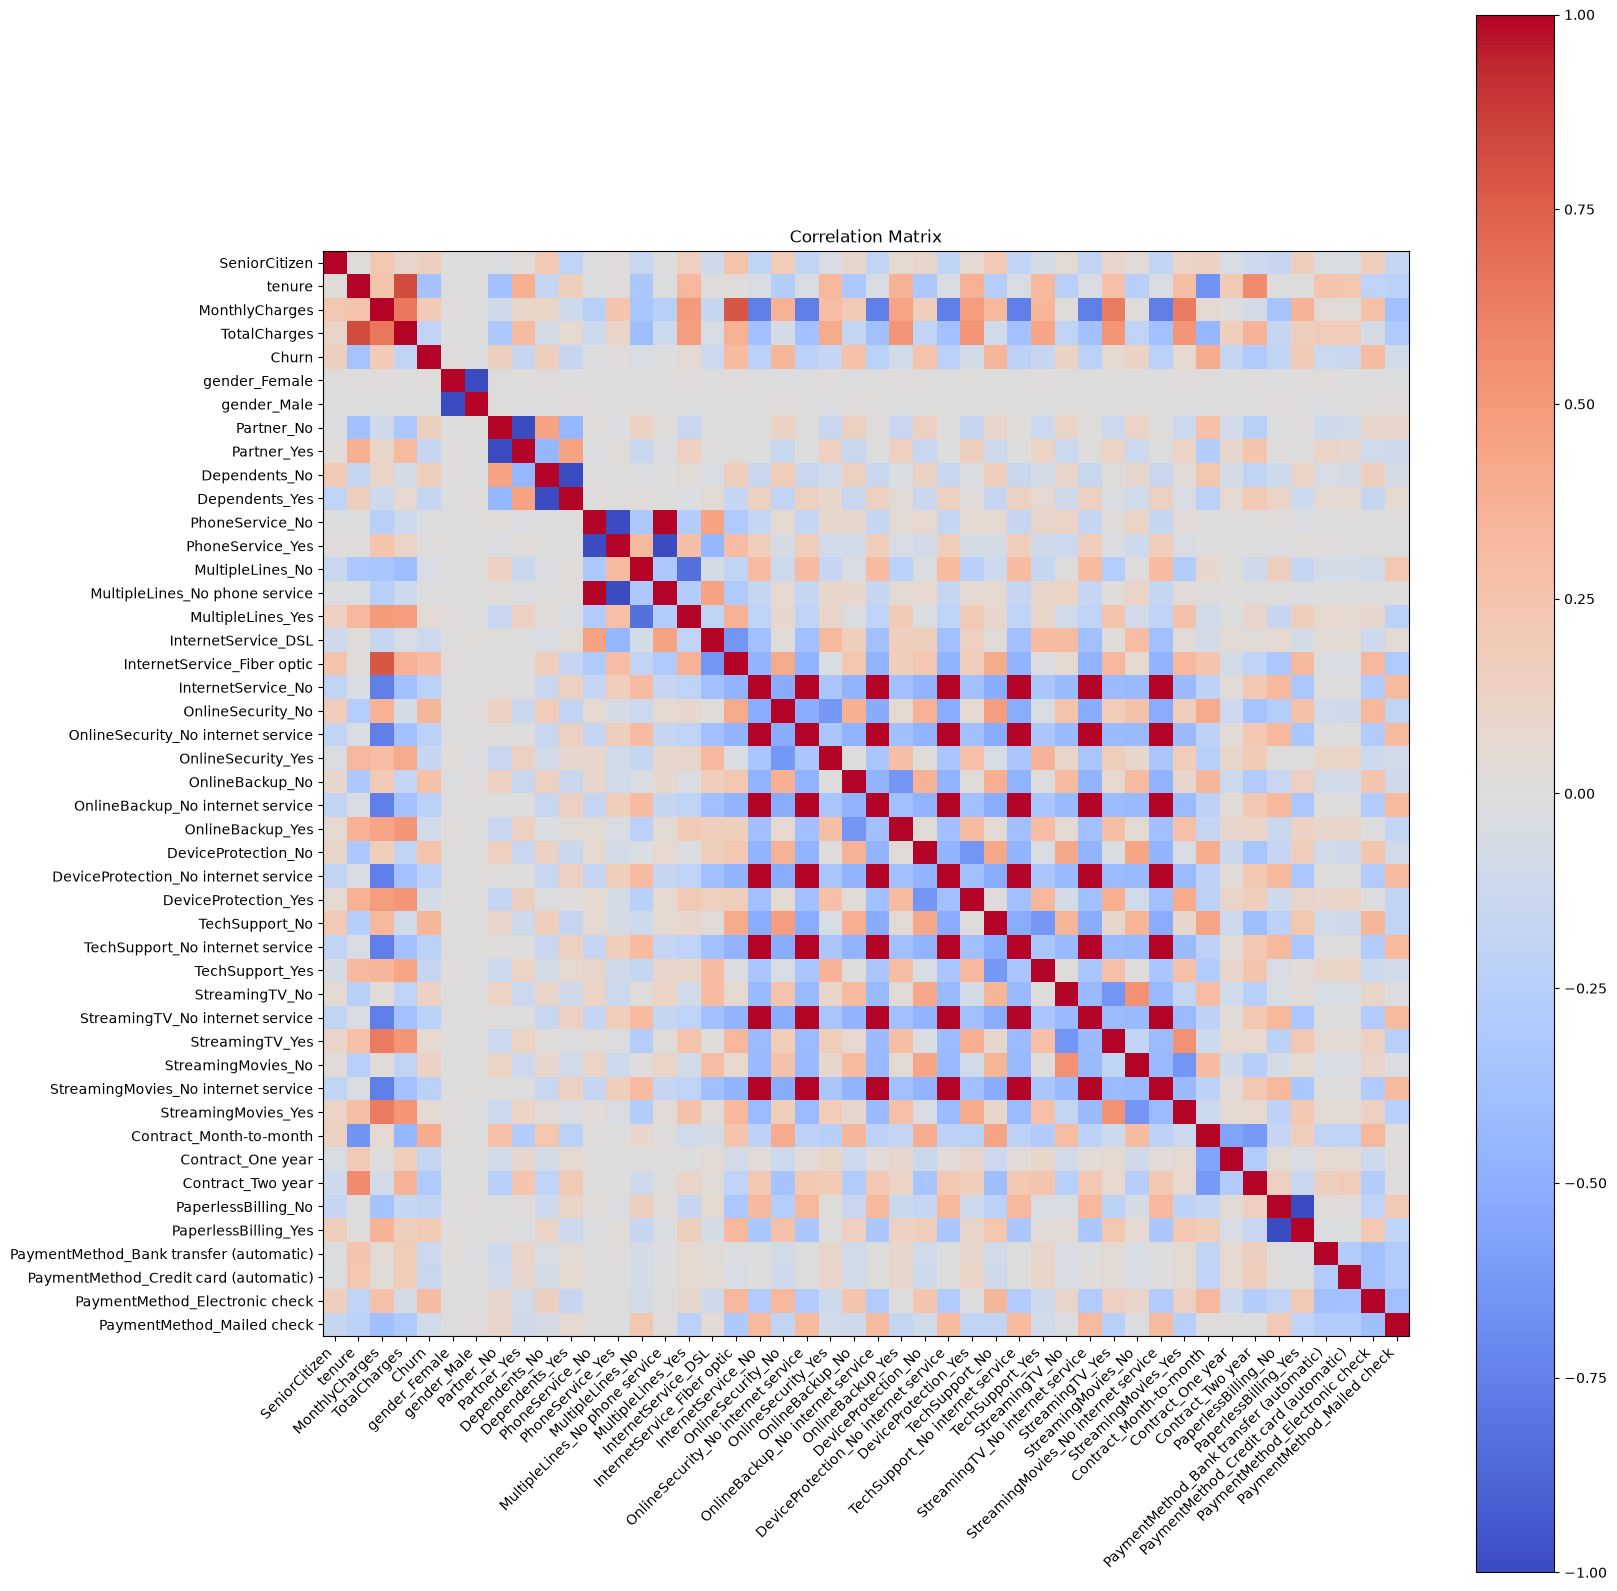

In [35]:
# # 1. Calculate the correlation matrix
corr_matrix = df_3.corr()

# 2. Plot using Matplotlib
fig, ax = plt.subplots(figsize=(17, 17))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Add colorbar and labels
fig.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.columns)
ax.set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

In [36]:
df.groupby("Churn")[["tenure", "MonthlyCharges"]].mean().round(1)

,tenure,MonthlyCharges
Churn,,
No,37.6,61.3
Yes,18.0,74.4


# **Modeling**
- Random Forest
- Logistic Regression 
- Decision Tree (BASE MODEL)
- XG Boost
- ANN ( number of hidden layers, epochs,  early stopping)
- Saving the model 

In [37]:
df_3.dtypes

SeniorCitizen                                int64
tenure                                       int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
gender_Female                                 bool
gender_Male                                   bool
Partner_No                                    bool
Partner_Yes                                   bool
Dependents_No                                 bool
Dependents_Yes                                bool
PhoneService_No                               bool
PhoneService_Yes                              bool
MultipleLines_No                              bool
MultipleLines_No phone service                bool
MultipleLines_Yes                             bool
InternetService_DSL                           bool
InternetService_Fiber optic                   bool
InternetService_No                            bool
OnlineSecurity_No              

In [38]:
df_3.isna().sum()/len(df_3)

SeniorCitizen                              0.0
tenure                                     0.0
MonthlyCharges                             0.0
TotalCharges                               0.0
Churn                                      0.0
gender_Female                              0.0
gender_Male                                0.0
Partner_No                                 0.0
Partner_Yes                                0.0
Dependents_No                              0.0
Dependents_Yes                             0.0
PhoneService_No                            0.0
PhoneService_Yes                           0.0
MultipleLines_No                           0.0
MultipleLines_No phone service             0.0
MultipleLines_Yes                          0.0
InternetService_DSL                        0.0
InternetService_Fiber optic                0.0
InternetService_No                         0.0
OnlineSecurity_No                          0.0
OnlineSecurity_No internet service         0.0
OnlineSecurit

split the data

In [39]:

X = df_3.drop(columns=["Churn"])
y = df_3.Churn

In [40]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,True,False,False,True,True,False,...,False,True,False,False,False,True,False,False,True,False
1,0,34,56.95,1889.50,False,True,True,False,True,False,...,False,False,True,False,True,False,False,False,False,True
2,0,2,53.85,108.15,False,True,True,False,True,False,...,False,True,False,False,False,True,False,False,False,True
3,0,45,42.30,1840.75,False,True,True,False,True,False,...,False,False,True,False,True,False,True,False,False,False
4,0,2,70.70,151.65,True,False,True,False,True,False,...,False,True,False,False,False,True,False,False,True,False


In [41]:
y.head(2)

0    0
1    0
Name: Churn, dtype: int64

In [42]:
X.shape

(7032, 45)

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3, 
    random_state=42, 
    stratify= y # it will retain a constant proportion when splitting the two classes
)

instantialte the models 

In [69]:
classical_models = {
    "DecisionTreeClassifier":DecisionTreeClassifier(max_depth= 20, min_samples_leaf=10,  criterion='entropy', random_state = SEED_VALUE,),
    "logistic_regression": LogisticRegression(max_iter=10000), 
    "random_forest": RandomForestClassifier(n_estimators=1000, min_samples_leaf=10, random_state= SEED_VALUE), 
    "xgboost": XGBClassifier(
        n_estimators = 3000, max_depth = 20, learning_rate=0.01, eval_metric="logloss", random_state =SEED_VALUE 
    )
}

In [81]:
# get classical model 
# train the model 
# save the model 

for name, model in classical_models.items(): 
    #  get model&   train model
    model.fit(X_train, y_train)
    #  save model
    joblib.dump(model, f"{name}_model.joblib")
    
    #  predict value

KeyboardInterrupt: 

# **Evaluation**

In [71]:
# evaluation function ( accuracy, precision., recall, f1-score, roc_auc)
def evaluationCalculator(y_test, proba, threshold = 0.5 ):
    pred = (proba>threshold).astype(int)
    return {
        "accuracy": f"{accuracy_score(y_test, pred):.2f}", 
        "precision":f"{precision_score(y_test, pred):.2f}",
        "recall":f"{recall_score(y_test, pred):.2f}",
        "f1-score":f"{f1_score(y_test, pred):.2f}",
        "roc_auc-score":f"{roc_auc_score(y_test, pred):.2f}"
    }


In [102]:
probability_values = {}
model_outcome_evals = []

for name, model in classical_models.items(): 
    #  get model&   train model
    model.fit(X_train, y_train) 
    #  get the prob values
    probability_values[name] = lambda X, m = model: model.predict_proba(X)[:,1]
    evaluation = evaluationCalculator(y_test=y_test,proba=probability_values[name](X_test))

    model_outcome_evals.append(
        {
            "model": name, 
            "evaluation": evaluation
        }
    )

    #  evaluate the model
    print("="*40, f"{name}", "="*40) 
    print(evaluation)
    print("="*100) 
    #  print score

======================================== DecisionTreeClassifier ========================================
{'accuracy': '0.77', 'precision': '0.58', 'recall': '0.50', 'f1-score': '0.54', 'roc_auc-score': '0.68'}
======================================== logistic_regression ========================================
{'accuracy': '0.81', 'precision': '0.66', 'recall': '0.57', 'f1-score': '0.61', 'roc_auc-score': '0.73'}
======================================== random_forest ========================================
{'accuracy': '0.79', 'precision': '0.64', 'recall': '0.48', 'f1-score': '0.55', 'roc_auc-score': '0.69'}
======================================== xgboost ========================================
{'accuracy': '0.77', 'precision': '0.59', 'recall': '0.51', 'f1-score': '0.54', 'roc_auc-score': '0.69'}


In [68]:
probability_values = {}

for name, model in classical_models.items(): 
    #  get model&   train model
    model.fit(X_train, y_train) 
    #  get the prob values
    probability_values[name] = lambda X, m = model: model.predict_proba(X)[:,1]

    #  evaluate the model
    print("="*40, f"{name}", "="*40) 
    print(evaluationCalculator(y_test=y_test,proba=probability_values[name](X_test)))
    print("="*100) 
    #  print score

======================================== DecisionTreeClassifier ========================================
{'accuracy': '0.77', 'precision': '0.58', 'recall': '0.50', 'f1-score': '0.54', 'roc_auc-score': '0.68'}
======================================== logistic_regression ========================================
{'accuracy': '0.81', 'precision': '0.66', 'recall': '0.57', 'f1-score': '0.61', 'roc_auc-score': '0.73'}
======================================== random_forest ========================================
{'accuracy': '0.79', 'precision': '0.64', 'recall': '0.48', 'f1-score': '0.55', 'roc_auc-score': '0.69'}
======================================== xgboost ========================================
{'accuracy': '0.77', 'precision': '0.58', 'recall': '0.51', 'f1-score': '0.54', 'roc_auc-score': '0.69'}


In [72]:
probability_values = {}

for name, model in classical_models.items(): 
    #  get model&   train model
    model.fit(X_train, y_train) 
    #  get the prob values
    probability_values[name] = lambda X, m = model: model.predict_proba(X)[:,1]

    #  evaluate the model
    print("="*40, f"{name}", "="*40) 
    print(evaluationCalculator(y_test=y_test,proba=probability_values[name](X_test)))
    print("="*100) 
    #  print score

======================================== DecisionTreeClassifier ========================================
{'accuracy': '0.77', 'precision': '0.58', 'recall': '0.50', 'f1-score': '0.54', 'roc_auc-score': '0.68'}
======================================== logistic_regression ========================================
{'accuracy': '0.81', 'precision': '0.66', 'recall': '0.57', 'f1-score': '0.61', 'roc_auc-score': '0.73'}
======================================== random_forest ========================================
{'accuracy': '0.79', 'precision': '0.64', 'recall': '0.48', 'f1-score': '0.55', 'roc_auc-score': '0.69'}
======================================== xgboost ========================================
{'accuracy': '0.77', 'precision': '0.59', 'recall': '0.51', 'f1-score': '0.54', 'roc_auc-score': '0.69'}


In [59]:
probability_values

{'DecisionTreeClassifier': <function __main__.<lambda>(X, m=DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=10,
                       random_state=42))>,
 'logistic_regression': <function __main__.<lambda>(X, m=LogisticRegression(max_iter=10000))>,
 'random_forest': <function __main__.<lambda>(X, m=RandomForestClassifier(min_samples_leaf=5, n_estimators=300, random_state=42))>,
 'xgboost': <function __main__.<lambda>(X, m=XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta

In [95]:
# Neural Net  - has 3 hidden layers with 1st layer having 64 neurons, 2nd - 32 neuron, 3rd 16 neurons


#  model definiton
dnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1], )),          # one customer = n_features numbers

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3), 

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3), 

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.3), 

    tf.keras.layers.Dense(1, activation="sigmoid") # OUTPUT: 1 neuron, a probability between 0 and 1
])

dnn_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 128)            │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,257 (63.50 KB)

 Trainable params: 16,257 (63.50 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:

#  compilation
dnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="roc_auc")]
)

In [97]:
#e arly stopping
early_stop = tf.keras.callbacks.EarlyStopping( monitor="val_loss", patience=10, restore_best_weights=True)

#  run predictions
history = dnn_model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6565 - loss: 19.8279 - roc_auc: 0.5589 - val_accuracy: 0.7497 - val_loss: 0.8522 - val_roc_auc: 0.6198
Epoch 2/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6701 - loss: 3.3741 - roc_auc: 0.5899 - val_accuracy: 0.6861 - val_loss: 0.6303 - val_roc_auc: 0.6038
Epoch 3/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6945 - loss: 1.5182 - roc_auc: 0.6138 - val_accuracy: 0.7375 - val_loss: 0.6185 - val_roc_auc: 0.6241
Epoch 4/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7227 - loss: 1.1481 - roc_auc: 0.6058 - val_accuracy: 0.7375 - val_loss: 0.6009 - val_roc_auc: 0.6175
Epoch 5/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7313 - loss: 0.8149 - roc_auc: 0.6103 - val_accuracy: 0.7375 - val_loss: 0.6127 - val_roc_auc: 0.6149
Epoch 6/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7344 - loss: 0.8354 - roc_auc: 0.6164 - val_accuracy: 0.7375 - val_loss: 0.5858 - val_

In [98]:
#  saves the model
dnn_model.save("dnn.keras")

In [104]:

    #  get model&   train model
dnn_model.fit(X_train, y_train) 
    #  get the prob values
probability_values["deep_neural_net"] = lambda X : dnn_model.predict(X, verbose=1).ravel()
dnn_evaluation = evaluationCalculator(y_test=y_test,proba=probability_values["deep_neural_net"](X_test))

model_outcome_evals.append( 

    {"model":"deep_neural_net", 
    "evaluation":dnn_evaluation}
)
    #  evaluate the model
print("="*40,  "deep_neural_net", "="*40) 
print(dnn_evaluation)
print("="*100) 

154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7920 - loss: 0.4634 - roc_auc: 0.7973
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
======================================== deep_neural_net ========================================
{'accuracy': '0.78', 'precision': '0.76', 'recall': '0.26', 'f1-score': '0.39', 'roc_auc-score': '0.62'}


In [93]:
probability_values

{'DecisionTreeClassifier': <function __main__.<lambda>(X, m=DecisionTreeClassifier(criterion='entropy', max_depth=20, min_samples_leaf=10,
                       random_state=42))>,
 'logistic_regression': <function __main__.<lambda>(X, m=LogisticRegression(max_iter=10000))>,
 'random_forest': <function __main__.<lambda>(X, m=RandomForestClassifier(min_samples_leaf=10, n_estimators=1000, random_state=42))>,
 'xgboost': <function __main__.<lambda>(X, m=XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_de

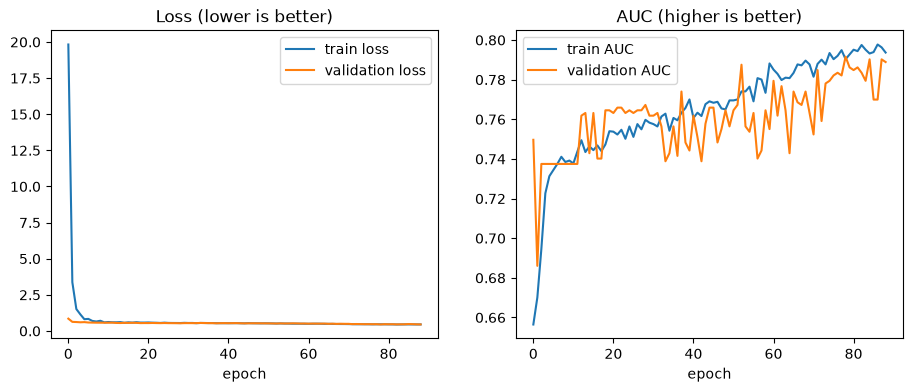

In [101]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(history.history["loss"], label="train loss")
ax[0].plot(history.history["val_loss"], label="validation loss")
ax[0].set_title("Loss (lower is better)"); ax[0].set_xlabel("epoch"); ax[0].legend()

ax[1].plot(history.history["accuracy"], label="train AUC")
ax[1].plot(history.history["val_accuracy"], label="validation AUC")
ax[1].set_title("AUC (higher is better)"); ax[1].set_xlabel("epoch"); ax[1].legend()

plt.show()

In [110]:
for model_outcome in model_outcome_evals:
    print(f"{model_outcome['model']} \n{model_outcome['evaluation']}\n")
    print("-"*100)

DecisionTreeClassifier 
{'accuracy': '0.77', 'precision': '0.58', 'recall': '0.50', 'f1-score': '0.54', 'roc_auc-score': '0.68'}

----------------------------------------------------------------------------------------------------
logistic_regression 
{'accuracy': '0.81', 'precision': '0.66', 'recall': '0.57', 'f1-score': '0.61', 'roc_auc-score': '0.73'}

----------------------------------------------------------------------------------------------------
random_forest 
{'accuracy': '0.79', 'precision': '0.64', 'recall': '0.48', 'f1-score': '0.55', 'roc_auc-score': '0.69'}

----------------------------------------------------------------------------------------------------
xgboost 
{'accuracy': '0.77', 'precision': '0.59', 'recall': '0.51', 'f1-score': '0.54', 'roc_auc-score': '0.69'}

----------------------------------------------------------------------------------------------------
deep_neural_net 
{'accuracy': '0.79', 'precision': '0.68', 'recall': '0.38', 'f1-score': '0.49', 'roc_a

## Hyper parameter tuning

https://www.geeksforgeeks.org/machine-learning/hyperparameter-tuning/

# **Deployment**

- PowerBI
- FastAPI 
- Streamlit

(XAI)